# 01 - EDA : IEEE-CIS Fraud Detection

**Étape CRISP-DM : Data Understanding**

Objectif de ce notebook :
1. Charger `train_transaction.csv` (590 540 lignes x 394 colonnes) sans saturer la RAM
2. Fusionner avec `train_identity.csv`
3. Visualiser le déséquilibre des classes (fraude vs non-fraude)

Contrainte : le fichier en float64/int64 natif dépasse la RAM disponible sur ce poste.
Stratégie retenue : lecture par chunks de 50 000 lignes avec downcast float32/int32 à la volée.

In [1]:
import gc
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = os.path.join("..", "data", "raw")
TRANSACTION_PATH = os.path.join(DATA_DIR, "train_transaction.csv")
IDENTITY_PATH = os.path.join(DATA_DIR, "train_identity.csv")
CHUNK_SIZE = 50_000

sns.set_theme(style="whitegrid")

## Cellule 2 - Chargement chunké avec downcast mémoire

On lit le CSV par blocs de 50 000 lignes. Sur chaque bloc :
- les colonnes `float64` sont converties en `float32`
- les colonnes entières sont converties en `int32` (ou plus petit si possible)

Si malgré cette optimisation la RAM est encore insuffisante (`MemoryError`), on bascule
automatiquement sur un échantillon de 100 000 lignes (`nrows=100_000`) pour l'EDA.
Cette approche est documentée et assumée : à ce stade (exploration), un échantillon
représentatif suffit ; le pipeline d'entraînement final (module `src/pipeline.py`)
traitera le dataset complet via un chargement chunké + agrégation incrémentale, sans
jamais matérialiser l'intégralité du DataFrame en mémoire si ce n'est pas nécessaire.

In [2]:
def downcast_chunk(chunk: pd.DataFrame) -> pd.DataFrame:
    float_cols = chunk.select_dtypes(include=["float64"]).columns
    chunk[float_cols] = chunk[float_cols].astype(np.float32)

    int_cols = chunk.select_dtypes(include=["int64"]).columns
    for col in int_cols:
        chunk[col] = pd.to_numeric(chunk[col], downcast="integer")

    return chunk


def load_transactions_chunked(path: str, chunksize: int = CHUNK_SIZE) -> pd.DataFrame:
    chunks = []
    for i, chunk in enumerate(pd.read_csv(path, chunksize=chunksize)):
        chunk = downcast_chunk(chunk)
        chunks.append(chunk)
        print(f"Chunk {i + 1} charge : {len(chunk):,} lignes (cumul {sum(len(c) for c in chunks):,})")

    df = pd.concat(chunks, ignore_index=True)
    del chunks
    gc.collect()
    return df


FALLBACK_NROWS = 100_000

try:
    df_transaction = load_transactions_chunked(TRANSACTION_PATH)
    print(f"\nChargement complet reussi : {df_transaction.shape}")
except MemoryError:
    print(f"MemoryError sur le chargement complet -> fallback nrows={FALLBACK_NROWS:,} pour l'EDA")
    df_transaction = pd.read_csv(TRANSACTION_PATH, nrows=FALLBACK_NROWS)
    df_transaction = downcast_chunk(df_transaction)
    print(f"Chargement partiel (echantillon EDA) : {df_transaction.shape}")

mem_mb = df_transaction.memory_usage(deep=True).sum() / 1024**2
print(f"Memoire occupee par df_transaction : {mem_mb:.1f} Mo")

Chunk 1 charge : 50,000 lignes (cumul 50,000)


Chunk 2 charge : 50,000 lignes (cumul 100,000)


Chunk 3 charge : 50,000 lignes (cumul 150,000)


Chunk 4 charge : 50,000 lignes (cumul 200,000)


Chunk 5 charge : 50,000 lignes (cumul 250,000)


...

Chunk 10 charge : 50,000 lignes (cumul 500,000)


Chunk 11 charge : 50,000 lignes (cumul 550,000)


Chunk 12 charge : 40,540 lignes (cumul 590,540)



Chargement complet reussi : (590540, 394)


Memoire occupee par df_transaction : 1203.2 Mo


## Cellule 3 - Fusion avec `train_identity.csv` et déséquilibre des classes

In [3]:
df_identity = pd.read_csv(IDENTITY_PATH)
df_identity = downcast_chunk(df_identity)

df = df_transaction.merge(df_identity, on="TransactionID", how="left")
print(f"Shape apres fusion : {df.shape}")
print(f"Taux de couverture identity : {df['DeviceType'].notna().mean():.1%}")

del df_transaction, df_identity
gc.collect()

Shape apres fusion : (590540, 434)
Taux de couverture identity : 23.8%


0

Repartition des classes :
  Non-fraude (0) : 569,877 (96.50%)
  Fraude     (1) : 20,663 (3.50%)
  Ratio de desequilibre : 1:28


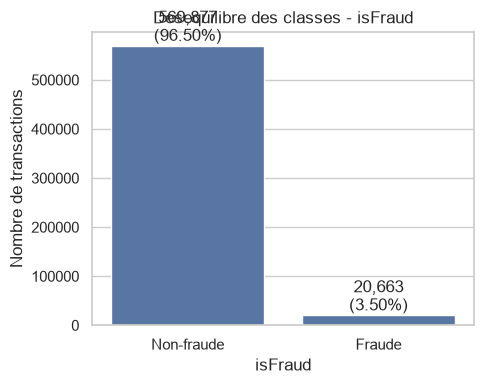

In [4]:
class_counts = df["isFraud"].value_counts()
class_pct = df["isFraud"].value_counts(normalize=True) * 100

print("Repartition des classes :")
print(f"  Non-fraude (0) : {class_counts[0]:,} ({class_pct[0]:.2f}%)")
print(f"  Fraude     (1) : {class_counts[1]:,} ({class_pct[1]:.2f}%)")
print(f"  Ratio de desequilibre : 1:{class_counts[0] / class_counts[1]:.0f}")

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, ax=ax)
ax.set_xticks(range(len(class_counts)))
ax.set_xticklabels(["Non-fraude", "Fraude"])
ax.set_ylabel("Nombre de transactions")
ax.set_title("Desequilibre des classes - isFraud")
for i, v in enumerate(class_counts.values):
    ax.text(i, v, f"{v:,}\n({class_pct.iloc[i]:.2f}%)", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## Cellule 4 - Valeurs manquantes

Les colonnes issues de `train_identity.csv` ne concernent que 23,8% des transactions (cf. plus haut) :
on s'attend donc à un bloc de colonnes avec ~76% de valeurs manquantes. L'objectif ici est de
distinguer ce "manquant structurel" (normal, à traiter en feature engineering plus tard) d'éventuelles
colonnes quasi-vides à envisager de supprimer.

Colonnes totales : 434
Colonnes sans aucune valeur manquante : 20
Colonnes avec plus de 90% de valeurs manquantes : 12
Colonnes avec plus de 50% de valeurs manquantes : 214

Top 15 colonnes les plus incompletes :
id_24    99.2
id_25    99.1
id_07    99.1
id_08    99.1
id_21    99.1
id_26    99.1
id_27    99.1
id_23    99.1
id_22    99.1
dist2    93.6
D7       93.4
id_18    92.4
D13      89.5
D14      89.5
D12      89.0
dtype: float64


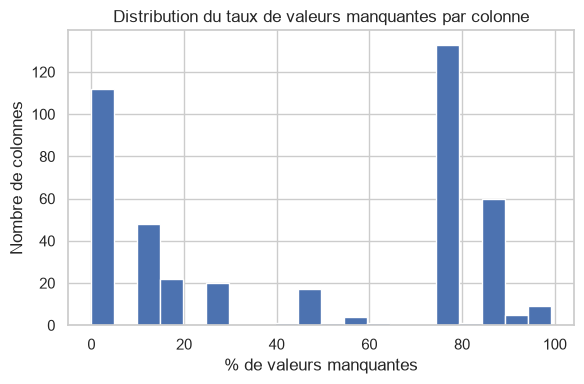

In [5]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

print(f"Colonnes totales : {df.shape[1]}")
print(f"Colonnes sans aucune valeur manquante : {(missing_pct == 0).sum()}")
print(f"Colonnes avec plus de 90% de valeurs manquantes : {(missing_pct > 90).sum()}")
print(f"Colonnes avec plus de 50% de valeurs manquantes : {(missing_pct > 50).sum()}")

print("\nTop 15 colonnes les plus incompletes :")
print(missing_pct.head(15).round(1))

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(missing_pct, bins=20, edgecolor="white")
ax.set_xlabel("% de valeurs manquantes")
ax.set_ylabel("Nombre de colonnes")
ax.set_title("Distribution du taux de valeurs manquantes par colonne")
plt.tight_layout()
plt.show()

## Cellule 5 - Typologie des variables

On sépare les colonnes par famille selon la documentation IEEE-CIS :
- **Identifiants** : `TransactionID`, `TransactionDT`
- **Cible** : `isFraud`
- **Catégorielles connues** : `ProductCD`, `card1-card6`, `addr1-addr2`, `P_emaildomain`, `R_emaildomain`,
  `M1-M9`, `DeviceType`, `DeviceInfo`, `id_12-id_38`
- **Numériques continues** : `TransactionAmt`, `C1-C14`, `D1-D15`, `V1-V339`

Cette typologie conditionne le preprocessing (encodage catégoriel vs scaling numérique) du module
`src/pipeline.py`.

In [6]:
ID_COLS = ["TransactionID", "TransactionDT"]
TARGET_COL = "isFraud"

CATEGORICAL_PREFIXES = ("card", "M", "id_")
CATEGORICAL_EXPLICIT = ["ProductCD", "addr1", "addr2", "P_emaildomain", "R_emaildomain",
                         "DeviceType", "DeviceInfo"]

categorical_cols = [
    c for c in df.columns
    if c in CATEGORICAL_EXPLICIT or c.startswith(CATEGORICAL_PREFIXES)
]
numerical_cols = [
    c for c in df.columns
    if c not in categorical_cols and c not in ID_COLS and c != TARGET_COL
]

print(f"Colonnes identifiants : {len(ID_COLS)}")
print(f"Colonne cible : 1 ({TARGET_COL})")
print(f"Colonnes categorielles : {len(categorical_cols)}")
print(f"Colonnes numeriques : {len(numerical_cols)}")
print(f"Total verifie : {len(ID_COLS) + 1 + len(categorical_cols) + len(numerical_cols)} / {df.shape[1]}")

print("\nCardinalite des colonnes categorielles principales :")
for col in ["ProductCD", "card4", "card6", "DeviceType", "P_emaildomain"]:
    print(f"  {col:20s} : {df[col].nunique()} valeurs uniques")

Colonnes identifiants : 2
Colonne cible : 1 (isFraud)
Colonnes categorielles : 60
Colonnes numeriques : 371
Total verifie : 434 / 434

Cardinalite des colonnes categorielles principales :
  ProductCD            : 5 valeurs uniques
  card4                : 4 valeurs uniques
  card6                : 4 valeurs uniques
  DeviceType           : 2 valeurs uniques
  P_emaildomain        : 59 valeurs uniques


## Cellule 6 - Taux de fraude par variable catégorielle clé

On croise `ProductCD`, `card4` (réseau de carte) et `DeviceType` avec `isFraud` pour repérer les
segments à risque. Un taux de fraude très supérieur à la moyenne globale (3,50%) sur un segment
volumineux serait un signal fort pour le feature engineering.


--- Taux de fraude par ProductCD ---
           n_transactions  taux_fraude
ProductCD                             
W                  439670         2.04
C                   68519        11.69
R                   37699         3.78
H                   33024         4.77
S                   11628         5.90



--- Taux de fraude par card4 ---
                  n_transactions  taux_fraude
card4                                        
visa                      384767         3.48
mastercard                189217         3.43
american express            8328         2.87
discover                    6651         7.73
NaN                         1577         2.60

--- Taux de fraude par DeviceType ---
            n_transactions  taux_fraude
DeviceType                             
NaN                 449730         2.10
desktop              85165         6.52
mobile               55645        10.17


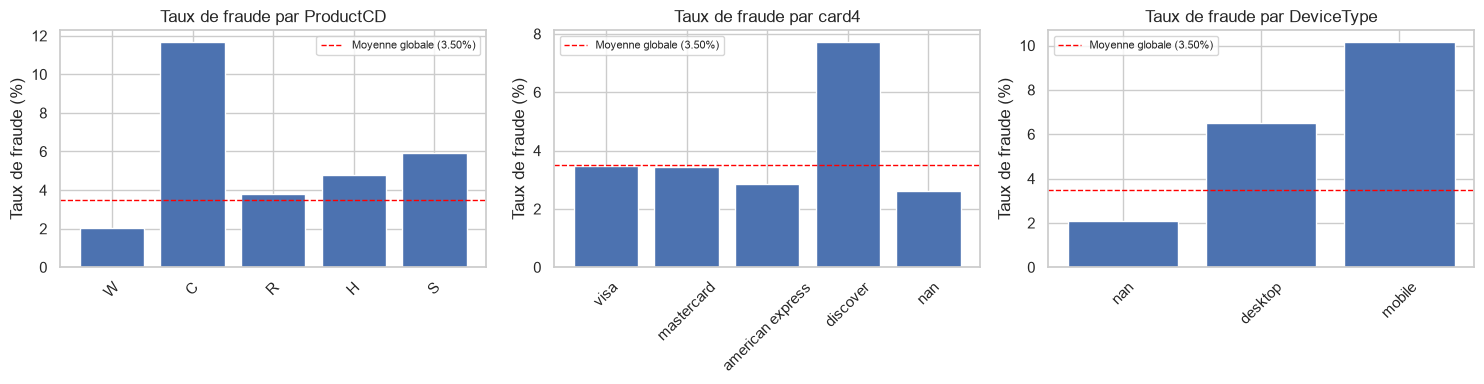

In [7]:
def fraud_rate_by(df: pd.DataFrame, col: str) -> pd.DataFrame:
    grouped = df.groupby(col, dropna=False)["isFraud"].agg(["count", "mean"])
    grouped = grouped.rename(columns={"count": "n_transactions", "mean": "taux_fraude"})
    grouped["taux_fraude"] = (grouped["taux_fraude"] * 100).round(2)
    return grouped.sort_values("n_transactions", ascending=False)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
overall_rate = df["isFraud"].mean() * 100

for ax, col in zip(axes, ["ProductCD", "card4", "DeviceType"]):
    stats = fraud_rate_by(df, col)
    print(f"\n--- Taux de fraude par {col} ---")
    print(stats)

    stats_plot = stats.head(8)
    ax.bar(stats_plot.index.astype(str), stats_plot["taux_fraude"], color="#4C72B0")
    ax.axhline(overall_rate, color="red", linestyle="--", linewidth=1, label=f"Moyenne globale ({overall_rate:.2f}%)")
    ax.set_title(f"Taux de fraude par {col}")
    ax.set_ylabel("Taux de fraude (%)")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()